# LiH: Comprehensive Statistical Analysis

Mirrors the H₂ comprehensive analysis. All sections include unmitigated, RF, and MLP.

1. Multi-seed MLP training (5 seeds, 2000 epochs)
2. Overfitting check (RF + MLP)
3. Bootstrap confidence intervals (all methods)
4. Additional metrics (R², max error, 90th percentile)
5. RF vs MLP significance test
6. MLP training diagnostics
7. Learned correction function (overall + per-observable sample)
8. Predicted vs ideal scatter plots
9. Residual analysis
10. Per-observable breakdown with CIs (sample of observables)
11. Feature ablation study

Data files: lih_ideal_data.npy, lih_noisy_data.npy, lih_theta_samples.npy, lih_rf_mlqem.joblib, lih_meta.json

## 0. Imports and Data Loading

In [1]:
import numpy as np
import json
import joblib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

plt.rcParams.update({'font.size': 12, 'axes.titlesize': 14, 'axes.labelsize': 12,
                     'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 10,
                     'figure.dpi': 150})
COLORS = {'unm': '#e74c3c', 'rf': '#3498db', 'ideal': '#2ecc71', 'mlp': '#9b59b6'}
print('All imports OK')

All imports OK


In [2]:
ideal_data = np.load('lih_ideal_data.npy')
noisy_data = np.load('lih_noisy_data.npy')
rf = joblib.load('lih_rf_mlqem.joblib')

with open('lih_meta.json') as f:
    meta = json.load(f)

PAULI_LABELS = meta['pauli_labels']
PAULI_COEFFS = meta['hamiltonian_coeffs']
N_QUBITS = meta['n_qubits']
ALL_OBS = list(range(1, len(PAULI_LABELS)))
N_TRAIN = 1800

print(f'Data: {ideal_data.shape[0]} samples, {ideal_data.shape[1]} Pauli terms, {N_QUBITS} qubits')

Data: 2000 samples, 62 Pauli terms, 6 qubits


In [3]:
from qiskit.quantum_info import Pauli
from qiskit_ibm_runtime.fake_provider import FakeJakartaV2

backend = FakeJakartaV2()
props = backend.properties()
qubit_props = {}
for q in range(N_QUBITS):
    qubit_props[q] = {
        'T1': props.qubit_property(q, 'T1')[0] * 1e6,
        'T2': props.qubit_property(q, 'T2')[0] * 1e6,
        'readout_error': props.qubit_property(q, 'readout_error')[0],
    }

SYMPLECTIC = {label: np.concatenate([Pauli(label).x.astype(int), Pauli(label).z.astype(int)])
              for label in PAULI_LABELS}
N_2Q = meta['n_2q_gates']
N_SX = meta['n_sx_gates']

def qubit_noise_features(symp):
    feats = []
    for q in range(N_QUBITS):
        active = float(symp[q] == 1 or symp[q + N_QUBITS] == 1)
        feats.extend([qubit_props[q]['T1']*active, qubit_props[q]['T2']*active,
                      qubit_props[q]['readout_error']*active])
    return feats

def build_features(noisy_subset, ideal_subset, obs_indices):
    rows_X, rows_y = [], []
    for obs_idx in obs_indices:
        label = PAULI_LABELS[obs_idx]
        symp = SYMPLECTIC[label]
        nf = qubit_noise_features(symp)
        for i in range(len(noisy_subset)):
            rows_X.append([noisy_subset[i, obs_idx], *symp, N_2Q, N_SX, *nf])
            rows_y.append(ideal_subset[i, obs_idx])
    return np.array(rows_X, dtype=np.float32), np.array(rows_y, dtype=np.float32)

X_train, y_train = build_features(noisy_data[:N_TRAIN], ideal_data[:N_TRAIN], ALL_OBS)
X_test, y_test = build_features(noisy_data[N_TRAIN:], ideal_data[N_TRAIN:], ALL_OBS)

train_pred_rf = rf.predict(X_train)
test_pred_rf = rf.predict(X_test)
baseline = X_test[:, 0]

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (109800, 33), Test: (12200, 33)


## 1. Train MLP (5 seeds, 2000 epochs)

In [4]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(),
            nn.Linear(hidden, 1))
    def forward(self, x): return self.net(x)
    def count_params(self): return sum(p.numel() for p in self.parameters() if p.requires_grad)

n_val = int(0.2 * len(X_train))
idx = np.random.RandomState(42).permutation(len(X_train))
val_idx, train_idx = idx[:n_val], idx[n_val:]
X_tr, y_tr = X_train[train_idx], y_train[train_idx]
X_val, y_val = X_train[val_idx], y_train[val_idx]

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_val_sc = scaler.transform(X_val)
X_te_sc = scaler.transform(X_test)
Xt = torch.tensor(X_tr_sc, dtype=torch.float32)
yt = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
Xv = torch.tensor(X_val_sc, dtype=torch.float32)
Xte = torch.tensor(X_te_sc, dtype=torch.float32)

N_MLP_SEEDS = 5
mlp_maes_all, mlp_preds_all, all_train_hists, all_val_hists = [], [], [], []

for seed in range(N_MLP_SEEDS):
    torch.manual_seed(seed)
    model = MLP(X_train.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    crit = nn.HuberLoss()
    best_val_mae, best_state, no_imp = float('inf'), None, 0
    t_hist, v_hist = [], []
    for epoch in range(2000):
        model.train(); opt.zero_grad(); crit(model(Xt), yt).backward(); opt.step()
        model.eval()
        with torch.no_grad():
            tr_m = mean_absolute_error(y_tr, model(Xt).numpy().ravel())
            vl_m = mean_absolute_error(y_val, model(Xv).numpy().ravel())
        t_hist.append(tr_m); v_hist.append(vl_m)
        if vl_m < best_val_mae - 1e-6:
            best_val_mae = vl_m; best_state = {k: v.clone() for k, v in model.state_dict().items()}; no_imp = 0
        else: no_imp += 1
        if no_imp >= 25: break
    model.load_state_dict(best_state); model.eval()
    with torch.no_grad():
        preds = model(Xte).numpy().ravel()
    s_mae = mean_absolute_error(y_test, preds)
    mlp_maes_all.append(s_mae); mlp_preds_all.append(preds)
    all_train_hists.append(t_hist); all_val_hists.append(v_hist)
    print(f'  Seed {seed}: MAE = {s_mae:.4f}, stopped at epoch {len(t_hist)}')

median_idx = np.argsort(mlp_maes_all)[N_MLP_SEEDS // 2]
mlp_test_pred = mlp_preds_all[median_idx]
train_hist = all_train_hists[median_idx]; val_hist = all_val_hists[median_idx]

# MLP train predictions for overfitting check
torch.manual_seed(median_idx)
model_final = MLP(X_train.shape[1]); model_final.load_state_dict(best_state); model_final.eval()
X_tr_all_sc = scaler.transform(X_train)
with torch.no_grad():
    train_pred_mlp = model_final(torch.tensor(X_tr_all_sc, dtype=torch.float32)).numpy().ravel()

mlp_mae_mean = np.mean(mlp_maes_all); mlp_mae_std = np.std(mlp_maes_all)
print(f'\nMLP across {N_MLP_SEEDS} seeds: {mlp_mae_mean:.4f} ± {mlp_mae_std:.4f}')
print(f'Using median seed {median_idx} (MAE={mlp_maes_all[median_idx]:.4f})')

  Seed 0: MAE = 0.0121, stopped at epoch 1374
  Seed 1: MAE = 0.0122, stopped at epoch 1185
  Seed 2: MAE = 0.0122, stopped at epoch 1189
  Seed 3: MAE = 0.0121, stopped at epoch 1064
  Seed 4: MAE = 0.0122, stopped at epoch 1231

MLP across 5 seeds: 0.0122 ± 0.0001
Using median seed 4 (MAE=0.0122)


## 2. Overfitting Check

In [5]:
train_mae_rf = mean_absolute_error(y_train, train_pred_rf)
test_mae_rf = mean_absolute_error(y_test, test_pred_rf)
train_mae_mlp = mean_absolute_error(y_train, train_pred_mlp)
test_mae_mlp = mean_absolute_error(y_test, mlp_test_pred)

print(f'{"":20} {"Train MAE":>12} {"Test MAE":>12} {"Ratio":>8}')
print('-' * 54)
print(f'{"RF":<20} {train_mae_rf:>12.6f} {test_mae_rf:>12.6f} {test_mae_rf/train_mae_rf:>7.2f}x')
print(f'{"MLP (median seed)":<20} {train_mae_mlp:>12.6f} {test_mae_mlp:>12.6f} {test_mae_mlp/train_mae_mlp:>7.2f}x')

                        Train MAE     Test MAE    Ratio
------------------------------------------------------
RF                       0.006743     0.013536    2.01x
MLP (median seed)        0.012200     0.012181    1.00x


## 3. Bootstrap Confidence Intervals

In [6]:
rng = np.random.default_rng(42)
def bootstrap_mae_ci(true, pred, n_boot=1000, ci=95):
    errors = np.abs(true - pred)
    boot_maes = np.array([errors[rng.choice(len(errors), size=len(errors), replace=True)].mean() for _ in range(n_boot)])
    lo = np.percentile(boot_maes, (100-ci)/2); hi = np.percentile(boot_maes, 100-(100-ci)/2)
    return errors.mean(), lo, hi, boot_maes

mae_unm, lo_unm, hi_unm, boot_unm = bootstrap_mae_ci(y_test, baseline)
mae_rf, lo_rf, hi_rf, boot_rf = bootstrap_mae_ci(y_test, test_pred_rf)
mae_mlp, lo_mlp, hi_mlp, boot_mlp = bootstrap_mae_ci(y_test, mlp_test_pred)

print('Expectation Value MAE (95% Bootstrap CIs):')
print(f'  Unmitigated: {mae_unm:.4f}  [{lo_unm:.4f}, {hi_unm:.4f}]')
print(f'  RF:          {mae_rf:.4f}  [{lo_rf:.4f}, {hi_rf:.4f}]')
print(f'  MLP:         {mae_mlp:.4f}  [{lo_mlp:.4f}, {hi_mlp:.4f}]  (median seed)')
print(f'  MLP mean±std:{mlp_mae_mean:.4f} ± {mlp_mae_std:.4f}  (across {N_MLP_SEEDS} seeds)')

coeffs = np.array(PAULI_COEFFS)
E_ideal = ideal_data[N_TRAIN:] @ coeffs; E_noisy = noisy_data[N_TRAIN:] @ coeffs

rf_corrected = noisy_data[N_TRAIN:].copy()
mlp_corrected = noisy_data[N_TRAIN:].copy()
for obs_idx in ALL_OBS:
    label = PAULI_LABELS[obs_idx]; symp = SYMPLECTIC[label]; nf = qubit_noise_features(symp)
    N = 200
    feats = np.column_stack([noisy_data[N_TRAIN:, obs_idx], np.tile(symp, (N,1)),
                             np.full((N,1), N_2Q), np.full((N,1), N_SX), np.tile(nf, (N,1))]).astype(np.float32)
    rf_corrected[:, obs_idx] = rf.predict(feats)
    feats_sc = scaler.transform(feats)
    model_final.eval()
    with torch.no_grad():
        mlp_corrected[:, obs_idx] = model_final(torch.tensor(feats_sc, dtype=torch.float32)).numpy().ravel()

rf_corrected[:, 0] = 1.0; mlp_corrected[:, 0] = 1.0
E_rf = rf_corrected @ coeffs; E_mlp = mlp_corrected @ coeffs

e_mae_unm, e_lo_unm, e_hi_unm, _ = bootstrap_mae_ci(E_ideal, E_noisy)
e_mae_rf, e_lo_rf, e_hi_rf, _ = bootstrap_mae_ci(E_ideal, E_rf)
e_mae_mlp, e_lo_mlp, e_hi_mlp, _ = bootstrap_mae_ci(E_ideal, E_mlp)

print(f'\nEnergy MAE (95% Bootstrap CIs):')
print(f'  Unmitigated: {e_mae_unm:.5f} Ha  [{e_lo_unm:.5f}, {e_hi_unm:.5f}]')
print(f'  RF:          {e_mae_rf:.5f} Ha  [{e_lo_rf:.5f}, {e_hi_rf:.5f}]')
print(f'  MLP:         {e_mae_mlp:.5f} Ha  [{e_lo_mlp:.5f}, {e_hi_mlp:.5f}]')

Expectation Value MAE (95% Bootstrap CIs):
  Unmitigated: 0.0406  [0.0399, 0.0412]
  RF:          0.0135  [0.0134, 0.0137]
  MLP:         0.0122  [0.0120, 0.0124]  (median seed)
  MLP mean±std:0.0122 ± 0.0001  (across 5 seeds)

Energy MAE (95% Bootstrap CIs):
  Unmitigated: 0.01202 Ha  [0.01075, 0.01343]
  RF:          0.00477 Ha  [0.00431, 0.00527]
  MLP:         0.00440 Ha  [0.00389, 0.00489]


## 4. Additional Metrics

In [7]:
print(f'{"Metric":<20} {"Unmitigated":>14} {"RF":>14} {"MLP":>14}')
print('-' * 64)
for name, func in [('MAE', lambda t,p: np.abs(t-p).mean()), ('Max error', lambda t,p: np.abs(t-p).max()),
                    ('90th pct error', lambda t,p: np.percentile(np.abs(t-p), 90)),
                    ('R²', lambda t,p: r2_score(t, p))]:
    print(f'{name:<20} {func(y_test, baseline):>14.6f} {func(y_test, test_pred_rf):>14.6f} {func(y_test, mlp_test_pred):>14.6f}')

Metric                  Unmitigated             RF            MLP
----------------------------------------------------------------
MAE                        0.040577       0.013536       0.012181
Max error                  0.298261       0.116741       0.089226
90th pct error             0.089269       0.028016       0.025135
R²                         0.946289       0.994692       0.995633


## 5. RF vs MLP Significance Test

In [8]:
diff_boot = boot_mlp - boot_rf
ci_lower = np.percentile(diff_boot, 2.5); ci_upper = np.percentile(diff_boot, 97.5)
print(f'RF MAE:  {mae_rf:.4f}  [{lo_rf:.4f}, {hi_rf:.4f}]')
print(f'MLP MAE: {mae_mlp:.4f}  [{lo_mlp:.4f}, {hi_mlp:.4f}]')
print(f'\nDifference (MLP - RF): {diff_boot.mean():.4f}  [{ci_lower:.4f}, {ci_upper:.4f}]')
if ci_lower > 0: print('Significant: Yes — RF is significantly better')
elif ci_upper < 0: print('Significant: Yes — MLP is significantly better')
else: print('Significant: No — difference not significant')

RF MAE:  0.0135  [0.0134, 0.0137]
MLP MAE: 0.0122  [0.0120, 0.0124]

Difference (MLP - RF): -0.0014  [-0.0016, -0.0011]
Significant: Yes — MLP is significantly better


## 6. MLP Training Diagnostics

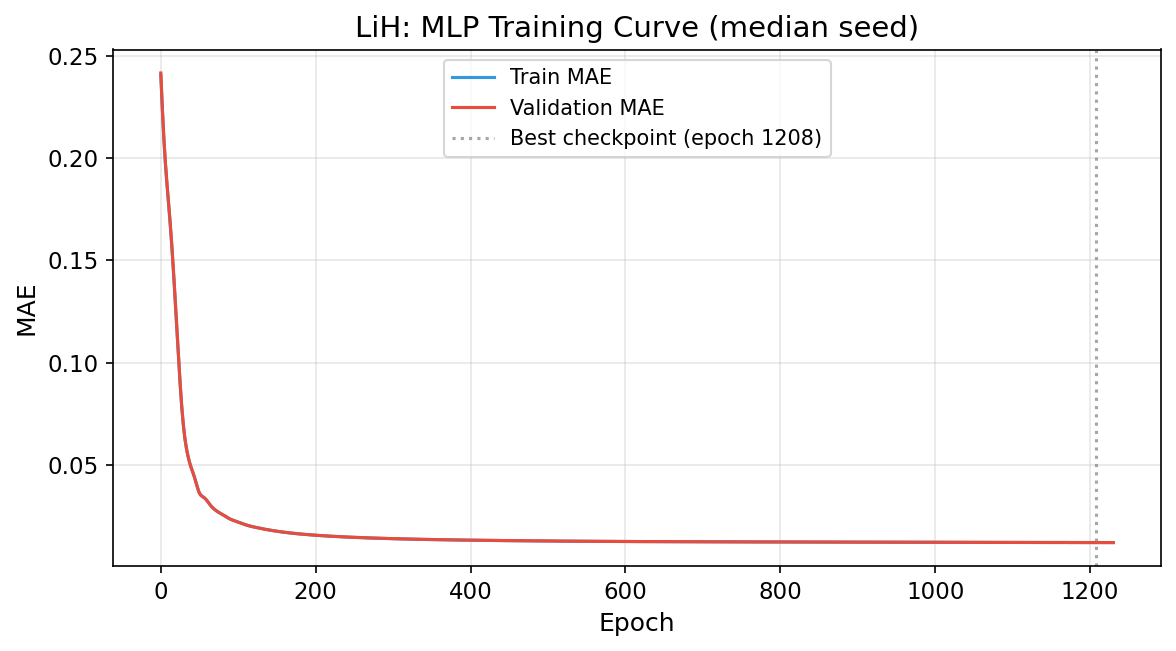

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(train_hist, label='Train MAE', color=COLORS['rf'])
ax.plot(val_hist, label='Validation MAE', color=COLORS['unm'])
best_epoch = np.argmin(val_hist)
ax.axvline(best_epoch, color='gray', linestyle=':', alpha=0.7, label=f'Best checkpoint (epoch {best_epoch+1})')
ax.set_xlabel('Epoch'); ax.set_ylabel('MAE'); ax.set_title('LiH: MLP Training Curve (median seed)')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('lih_mlp_training_curve.png', dpi=150, bbox_inches='tight'); plt.show()

## 7. Learned Correction Function

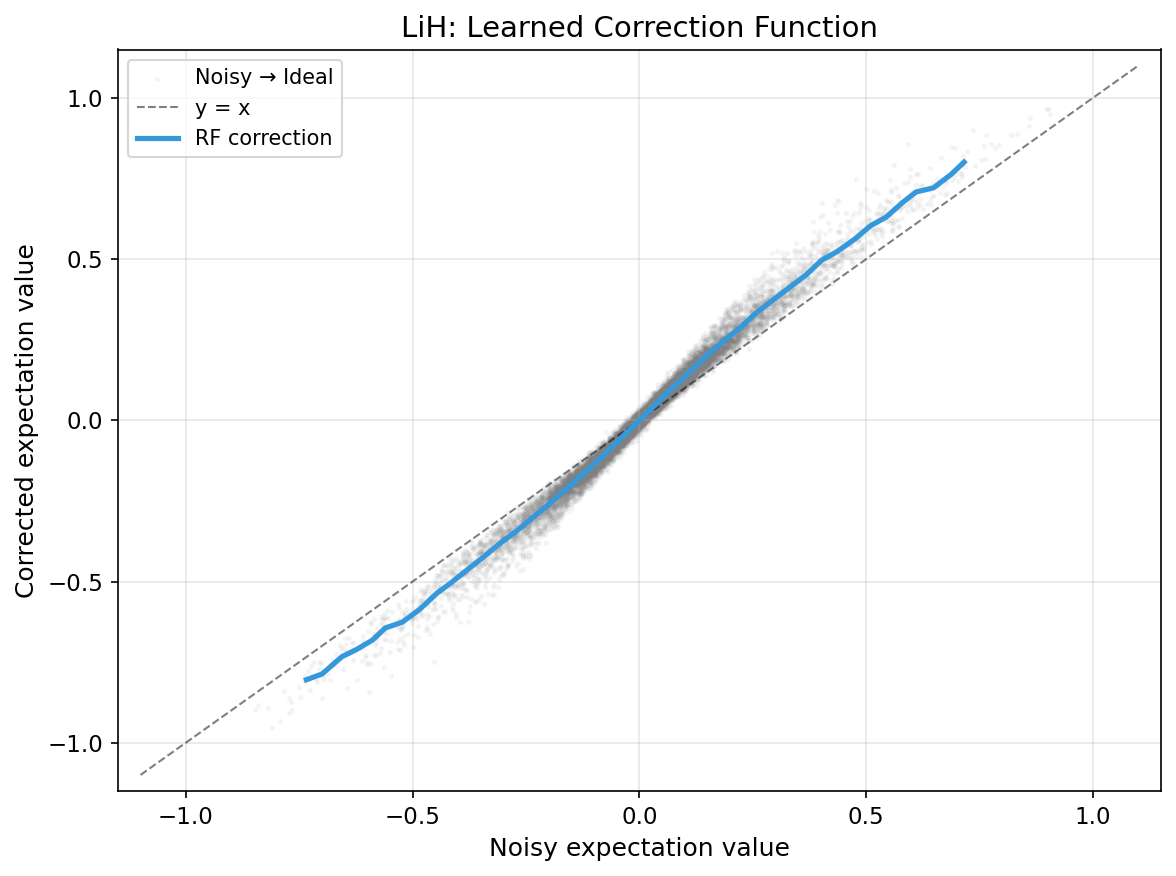

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(baseline, y_test, alpha=0.05, s=3, color='gray', label='Noisy → Ideal', zorder=1)
ax.plot([-1.1, 1.1], [-1.1, 1.1], 'k--', linewidth=1, alpha=0.5, label='y = x')
n_bins = 50
bin_edges = np.linspace(baseline.min()-0.01, baseline.max()+0.01, n_bins+1)
bc, bm = [], []
for k in range(n_bins):
    mask = (baseline >= bin_edges[k]) & (baseline < bin_edges[k+1])
    if mask.sum() > 5: bc.append(baseline[mask].mean()); bm.append(test_pred_rf[mask].mean())
ax.plot(bc, bm, color=COLORS['rf'], linewidth=2.5, label='RF correction', zorder=3)
ax.set_xlabel('Noisy expectation value'); ax.set_ylabel('Corrected expectation value')
ax.set_title('LiH: Learned Correction Function')
ax.legend(); ax.grid(alpha=0.3); ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15)
plt.tight_layout(); plt.savefig('lih_correction_function.png', dpi=150, bbox_inches='tight'); plt.show()

## 8. Predicted vs Ideal Scatter Plot

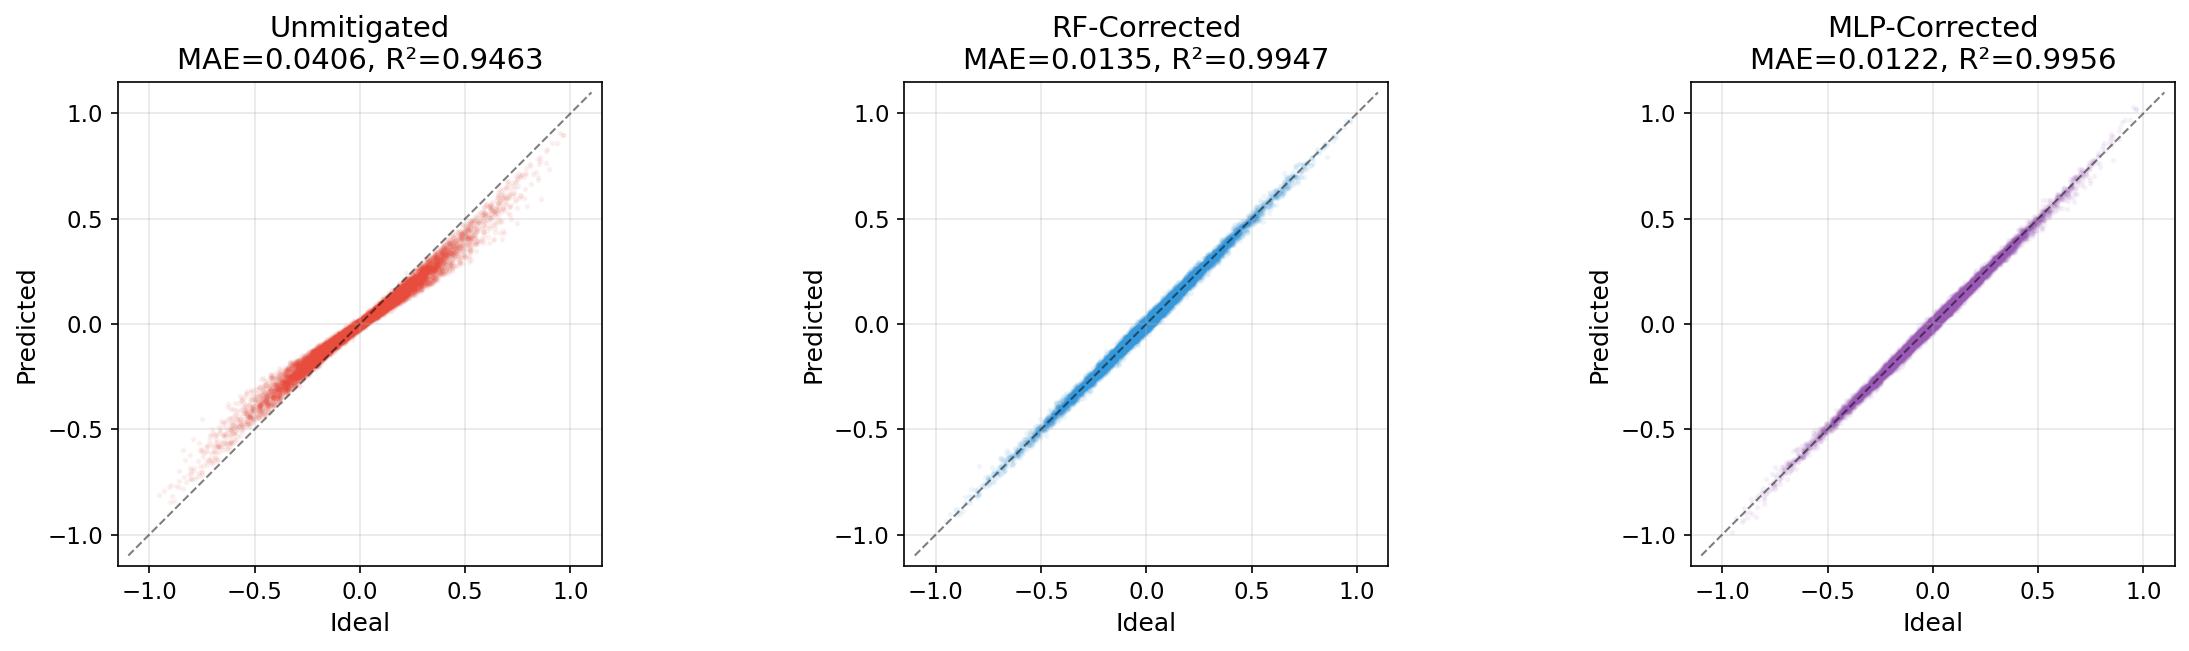

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, pred, name, color in [(axes[0], baseline, 'Unmitigated', COLORS['unm']),
                               (axes[1], test_pred_rf, 'RF-Corrected', COLORS['rf']),
                               (axes[2], mlp_test_pred, 'MLP-Corrected', COLORS['mlp'])]:
    ax.scatter(y_test, pred, alpha=0.05, s=3, color=color)
    ax.plot([-1.1, 1.1], [-1.1, 1.1], 'k--', linewidth=1, alpha=0.5)
    r2 = r2_score(y_test, pred); mae = mean_absolute_error(y_test, pred)
    ax.set_xlabel('Ideal'); ax.set_ylabel('Predicted')
    ax.set_title(f'{name}\nMAE={mae:.4f}, R²={r2:.4f}')
    ax.set_xlim(-1.15, 1.15); ax.set_ylim(-1.15, 1.15); ax.set_aspect('equal'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('lih_predicted_vs_ideal.png', dpi=150, bbox_inches='tight'); plt.show()

## 9. Residual Analysis

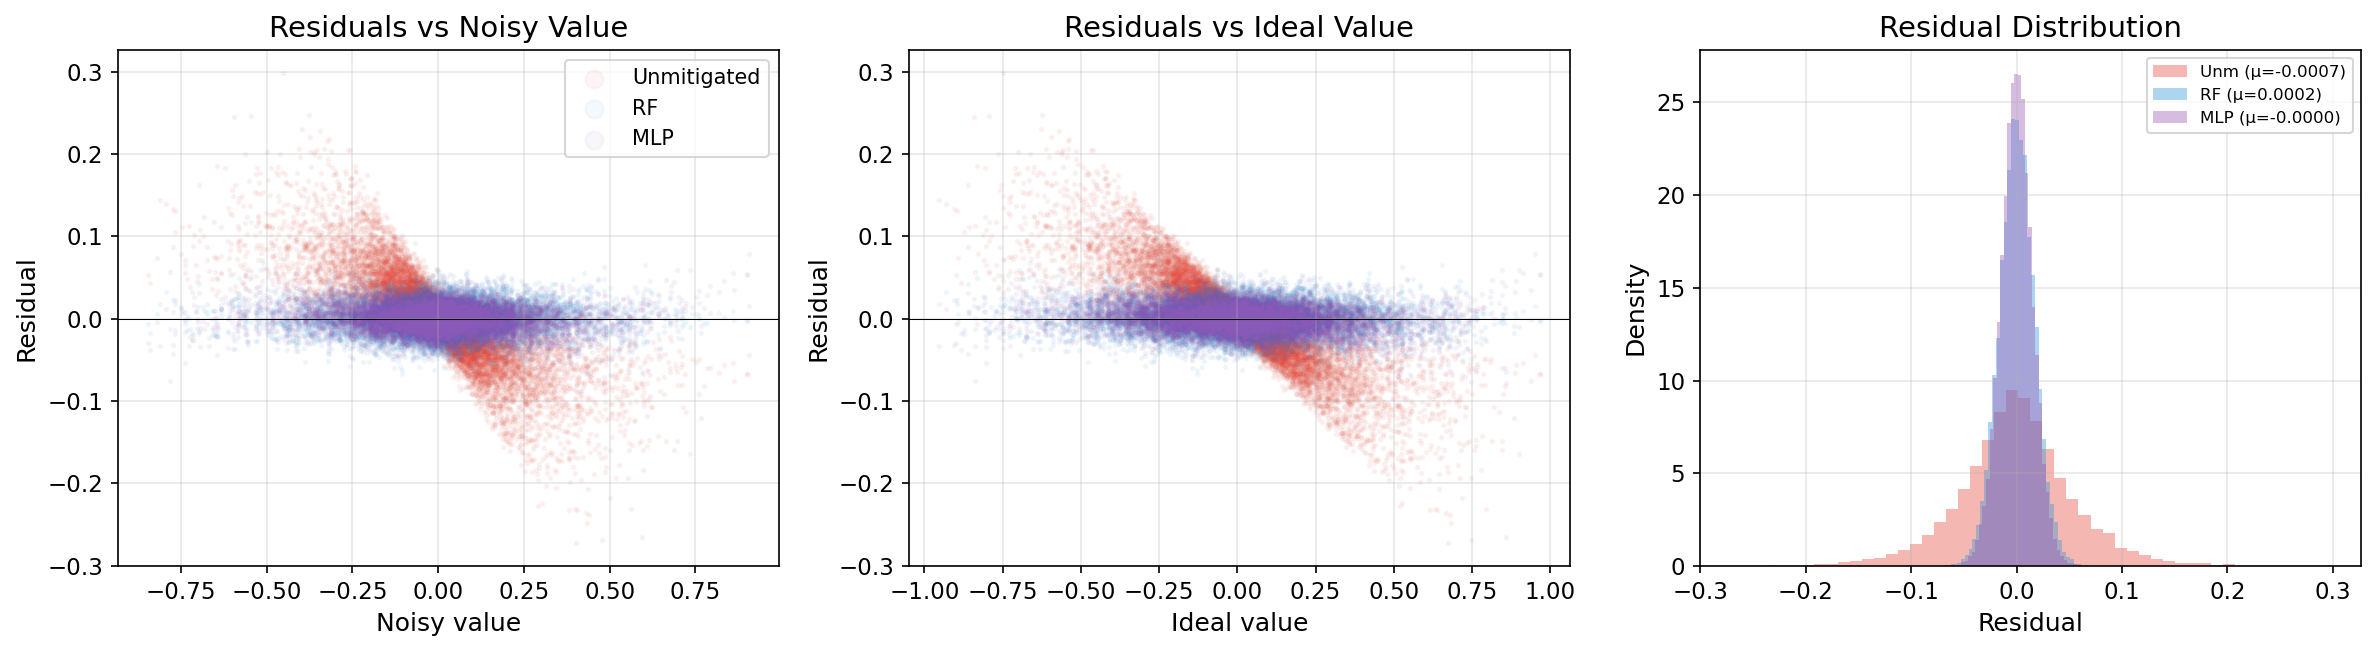

In [12]:
res_rf = test_pred_rf - y_test; res_mlp = mlp_test_pred - y_test; res_unm = baseline - y_test
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ax = axes[0]
ax.scatter(baseline, res_unm, alpha=0.05, s=3, color=COLORS['unm'], label='Unmitigated')
ax.scatter(baseline, res_rf, alpha=0.05, s=3, color=COLORS['rf'], label='RF')
ax.scatter(baseline, res_mlp, alpha=0.05, s=3, color=COLORS['mlp'], label='MLP')
ax.axhline(0, color='k', linewidth=0.5); ax.set_xlabel('Noisy value'); ax.set_ylabel('Residual')
ax.set_title('Residuals vs Noisy Value'); ax.legend(markerscale=5); ax.grid(alpha=0.3)
ax = axes[1]
ax.scatter(y_test, res_unm, alpha=0.05, s=3, color=COLORS['unm'])
ax.scatter(y_test, res_rf, alpha=0.05, s=3, color=COLORS['rf'])
ax.scatter(y_test, res_mlp, alpha=0.05, s=3, color=COLORS['mlp'])
ax.axhline(0, color='k', linewidth=0.5); ax.set_xlabel('Ideal value'); ax.set_ylabel('Residual')
ax.set_title('Residuals vs Ideal Value'); ax.grid(alpha=0.3)
ax = axes[2]
ax.hist(res_unm, bins=50, alpha=0.4, color=COLORS['unm'], label=f'Unm (μ={res_unm.mean():.4f})', density=True)
ax.hist(res_rf, bins=50, alpha=0.4, color=COLORS['rf'], label=f'RF (μ={res_rf.mean():.4f})', density=True)
ax.hist(res_mlp, bins=50, alpha=0.4, color=COLORS['mlp'], label=f'MLP (μ={res_mlp.mean():.4f})', density=True)
ax.set_xlabel('Residual'); ax.set_ylabel('Density'); ax.set_title('Residual Distribution')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('lih_residual_analysis.png', dpi=150, bbox_inches='tight'); plt.show()

## 10. Feature Ablation Study

Noisy value only         : MAE = 0.0209  (1.9x)
+ Symplectic             : MAE = 0.0136  (3.0x)
+ Gate counts            : MAE = 0.0136  (3.0x)
+ Noise params (all)     : MAE = 0.0135  (3.0x)


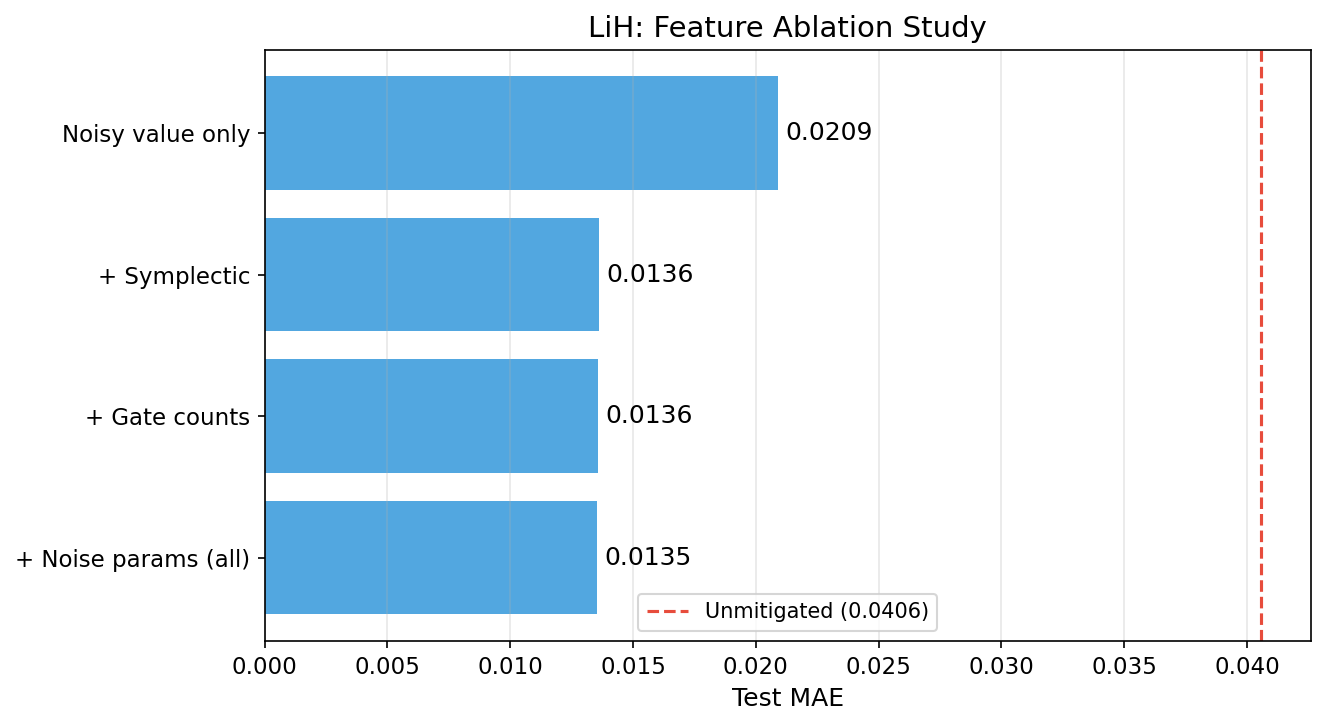

In [13]:
baseline_mae = mean_absolute_error(y_test, baseline)
# Feature indices for LiH (33 features):
# 0: noisy_val
# 1-12: symplectic (x_q0..x_q5, z_q0..z_q5)
# 13-14: gate counts (n_2q, n_sx)
# 15-32: noise params (T1_q0, T2_q0, ro_q0, ... for 6 qubits)
ablation_configs = [
    ('Noisy value only', [0]),
    ('+ Symplectic', list(range(13))),
    ('+ Gate counts', list(range(15))),
    ('+ Noise params (all)', list(range(33))),
]
abl_names, abl_maes = [], []
for name, feat_idx in ablation_configs:
    rf_abl = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_abl.fit(X_train[:, feat_idx], y_train)
    mae = mean_absolute_error(y_test, rf_abl.predict(X_test[:, feat_idx]))
    abl_names.append(name); abl_maes.append(mae)
    print(f'{name:<25s}: MAE = {mae:.4f}  ({baseline_mae/mae:.1f}x)')

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(abl_names[::-1], abl_maes[::-1], color=COLORS['rf'], alpha=0.85)
ax.axvline(baseline_mae, color=COLORS['unm'], linestyle='--', linewidth=1.5, label=f'Unmitigated ({baseline_mae:.4f})')
for bar, val in zip(bars, abl_maes[::-1]):
    ax.text(val + 0.0003, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')
ax.set_xlabel('Test MAE'); ax.set_title('LiH: Feature Ablation Study')
ax.legend(); ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.savefig('lih_ablation_study.png', dpi=150, bbox_inches='tight'); plt.show()

## 11. Summary

In [15]:
print('='*70)
print('UPDATED TABLE 1 VALUES (LiH)')
print('='*70)
print(f'Unmitigated MAE: {mae_unm:.4f}  (95% CI: [{lo_unm:.4f}, {hi_unm:.4f}])')
print(f'RF MAE:          {mae_rf:.4f}  (95% CI: [{lo_rf:.4f}, {hi_rf:.4f}])')
print(f'MLP MAE:         {mlp_mae_mean:.4f} ± {mlp_mae_std:.4f}  (mean ± std, {N_MLP_SEEDS} seeds)')
print(f'MLP median seed: {mae_mlp:.4f}  (95% CI: [{lo_mlp:.4f}, {hi_mlp:.4f}])')
print()
print(f'Energy MAE — Unmitigated: {e_mae_unm:.5f} Ha  [{e_lo_unm:.5f}, {e_hi_unm:.5f}]')
print(f'Energy MAE — RF:          {e_mae_rf:.5f} Ha  [{e_lo_rf:.5f}, {e_hi_rf:.5f}]')
print(f'Energy MAE — MLP:         {e_mae_mlp:.5f} Ha  [{e_lo_mlp:.5f}, {e_hi_mlp:.5f}]')
print()
if ci_lower > 0: print('RF vs MLP: RF significantly better')
elif ci_upper < 0: print('RF vs MLP: MLP significantly better')
else: print('RF vs MLP: difference not significant')
print(f'  Diff 95% CI: [{ci_lower:.4f}, {ci_upper:.4f}]')
print()
print(f'RF overfitting: {test_mae_rf/train_mae_rf:.2f}x')
print(f'MLP overfitting: {test_mae_mlp/train_mae_mlp:.2f}x')
print()
print('ABLATION KEY FINDING:')
for i, (n, m) in enumerate(zip(abl_names, abl_maes)):
    print(f'  {n:<25s}: MAE = {m:.4f} ({baseline_mae/m:.1f}x)')

UPDATED TABLE 1 VALUES (LiH)
Unmitigated MAE: 0.0406  (95% CI: [0.0399, 0.0412])
RF MAE:          0.0135  (95% CI: [0.0134, 0.0137])
MLP MAE:         0.0122 ± 0.0001  (mean ± std, 5 seeds)
MLP median seed: 0.0122  (95% CI: [0.0120, 0.0124])

Energy MAE — Unmitigated: 0.01202 Ha  [0.01075, 0.01343]
Energy MAE — RF:          0.00477 Ha  [0.00431, 0.00527]
Energy MAE — MLP:         0.00440 Ha  [0.00389, 0.00489]

RF vs MLP: MLP significantly better
  Diff 95% CI: [-0.0016, -0.0011]

RF overfitting: 2.01x
MLP overfitting: 1.00x

ABLATION KEY FINDING:
  Noisy value only         : MAE = 0.0209 (1.9x)
  + Symplectic             : MAE = 0.0136 (3.0x)
  + Gate counts            : MAE = 0.0136 (3.0x)
  + Noise params (all)     : MAE = 0.0135 (3.0x)
